In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1234)

stations = ["G", "L", "B", "Z"]

# Demand rates during peak periods [1000 passengers/h]
demand_peak = np.array([
    [np.nan, 1.5, 2.2, 1.3],
    [np.nan, np.nan, 2.4, 1.1],
    [np.nan, np.nan, np.nan, 3.3],
    [np.nan, np.nan, np.nan, np.nan],
])

# Demand rates during off-peak periods [1000 passengers/h]
demand_offpeak = np.array([
    [np.nan, 0.4, 0.3, 0.5],
    [np.nan, np.nan, 0.5, 0.3],
    [np.nan, np.nan, np.nan, 0.5],
    [np.nan, np.nan, np.nan, np.nan],
])

# Proportion of first class passengers during peak periods
first_class_ratio_peak = np.array([
    [np.nan, 0.13, 0.15, 0.17],
    [np.nan, np.nan, 0.21, 0.18],
    [np.nan, np.nan, np.nan, 0.32],
    [np.nan, np.nan, np.nan, np.nan],
])

# Proportion of first class passengers during off-peak periods
first_class_ratio_offpeak = np.array([
    [np.nan, 0.21, 0.18, 0.23],
    [np.nan, np.nan, 0.24, 0.23],
    [np.nan, np.nan, np.nan, 0.19],
    [np.nan, np.nan, np.nan, np.nan],
])

df_demand_peak = pd.DataFrame(demand_peak, index=stations, columns=stations)
df_demand_offpeak = pd.DataFrame(demand_offpeak, index=stations, columns=stations)
df_first_class_ratio_peak = pd.DataFrame(first_class_ratio_peak, index=stations, columns=stations)
df_first_class_ratio_offpeak = pd.DataFrame(first_class_ratio_offpeak, index=stations, columns=stations)

In [53]:
def exponential_rng(lam=1.0):
    """ Generates exponential random number. """
    if lam <= 0:
        return float('inf')
    return -np.log(np.random.rand()) / lam

# Price constants
PRICE_FIRST = 40
PRICE_SECOND = 20
MISSED_COST_FIRST = 30
MISSED_COST_SECOND = 10
EMPTY_COST_FIRST = 20
EMPTY_COST_SECOND = 10

def get_travel_time(station):
    """ Returns the travel time to the next station in minutes """
    if station == "G": return 40
    if station == "L": return 70
    if station == "B": return 60
    return 0

def get_num_stations(origin, destination):
    """ Calculates the number of stations between origin and destination for tickets """
    return stations.index(destination) - stations.index(origin)

def is_peak(time_minutes):
    """ Checks if we are in peak hours (7-9 or 16-18) """
    time_of_day = time_minutes % (24 * 60)
    # 7:00 = 420, 9:00 = 540, 16:00 = 960, 18:00 = 1080
    if (420 <= time_of_day <= 540) or (960 <= time_of_day <= 1080):
        return True
    return False

In [54]:
class Passenger:
    def __init__(self, arrival_time, origin, destination, is_first_class):
        self.arrival_time = arrival_time
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class
        self.missed_trains = 0

class Train:
    def __init__(self, train_id):
        self.train_id = train_id
        # Standard composition: 1 first class (300) and 3 second class (1500)
        self.capacity_first = 300 
        self.capacity_second = 3 * 500
        
        # Lists to keep track of passengers on board
        self.onboard_first = []
        self.onboard_second = []

In [55]:
class Event:
    """ Generic event. """
    def __init__(self, time):
        self.time = time

class PassengerGeneration(Event):
    """ A passenger arrives at the station """
    def __init__(self, time, origin, destination, is_first_class):
        super().__init__(time)
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class

class TrainArrival(Event):
    """ The train arrives at a station """
    def __init__(self, time, station, train):
        super().__init__(time)
        self.station = station
        self.train = train

In [56]:
def get_arrival_rate(origin, destination, is_first_class, time): # Calculates the arrival rate (lambda) in passengers per minute for a specific route and class
    peak = is_peak(time)
    
    # Choose the correct dataframe based on time
    if peak:
        demand_df = df_demand_peak
        ratio_df = df_first_class_ratio_peak
    else:
        demand_df = df_demand_offpeak
        ratio_df = df_first_class_ratio_offpeak
        
    total_demand_per_hour = demand_df.loc[origin, destination] * 1000
    
    # If NaN, the route does not exist
    if pd.isna(total_demand_per_hour):
        return 0
        
    first_class_ratio = ratio_df.loc[origin, destination]
    
    if is_first_class:
        rate_per_hour = total_demand_per_hour * first_class_ratio
    else:
        rate_per_hour = total_demand_per_hour * (1 - first_class_ratio)
        
    # Return the rate per minute
    return rate_per_hour / 60.0

def generate_timetable(freq_peak, freq_offpeak): # Generates all train arrival events for the day 
    train_events = []
    t = 0
    train_id = 0
    
    while t < 24 * 60:
        train = Train(train_id)
        current_time = t
        
        # Make the train travel through the stations
        for station in stations:
            train_events.append(TrainArrival(current_time, station, train))
            current_time += get_travel_time(station)
            
        if is_peak(t):
            t += freq_peak
        else:
            t += freq_offpeak
            
        train_id += 1
        
    return train_events

In [57]:
def simulate(train_frequency_peak, train_frequency_offpeak):
    
    # Initialize the queues at the stations 
    queues = {}
    for s in stations:
        queues[s] = {"first": [], "second": []}
        
    events = generate_timetable(train_frequency_peak, train_frequency_offpeak)
    
    # Generate the first passenger arrival event for each possible combination
    for origin in stations:
        for destination in stations:
            if stations.index(origin) >= stations.index(destination):
                continue
                
            for is_first in [True, False]:
                rate = get_arrival_rate(origin, destination, is_first, 0)
                if rate > 0:
                    time_first_arrival = exponential_rng(rate)
                    events.append(PassengerGeneration(time_first_arrival, origin, destination, is_first))
                    
    events.sort(key=lambda event: event.time)
    
    # State variables and statistics
    total_revenue = 0
    total_missed_cost = 0
    total_empty_cost = 0
    waiting_times = []
    
    # Lists to track queue over time for the plot
    time_history = []
    queue_history = []
    list_available_first = []
    list_available_second = []
    
    # Main loop
    while len(events) > 0:
        e = events.pop(0)
        
        if e.time > 24 * 60:
            break # End of the day
            
        if isinstance(e, PassengerGeneration):
            # 1. Add the passenger to the platform queue
            p = Passenger(e.time, e.origin, e.destination, e.is_first_class)
            if p.is_first_class:
                queues[e.origin]["first"].append(p)
            else:
                queues[e.origin]["second"].append(p)
                
            # 2. Schedule the next generation
            rate = get_arrival_rate(e.origin, e.destination, e.is_first_class, e.time)
            next_time = e.time + exponential_rng(rate)
            events.append(PassengerGeneration(next_time, e.origin, e.destination, e.is_first_class))
            
        elif isinstance(e, TrainArrival):
            train = e.train
            station = e.station
            
            # 1. Passengers get off
            train.onboard_first = [p for p in train.onboard_first if p.destination != station]
            train.onboard_second = [p for p in train.onboard_second if p.destination != station]
            
            # 2. Passengers board
            if station != "Z":
                # First class boarding
                available_first = train.capacity_first - len(train.onboard_first)
                left_behind_first = []
                for p in queues[station]["first"]:
                    if available_first > 0:
                        train.onboard_first.append(p)
                        available_first -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_FIRST * get_num_stations(p.origin, p.destination)
                        total_missed_cost += p.missed_trains * MISSED_COST_FIRST
                    else:
                        p.missed_trains += 1
                        left_behind_first.append(p)
                queues[station]["first"] = left_behind_first
                total_empty_cost += available_first * EMPTY_COST_FIRST
                list_available_first.append(available_first)
                
                # Second class boarding
                available_second = train.capacity_second - len(train.onboard_second)
                left_behind_second = []
                for p in queues[station]["second"]:
                    if available_second > 0:
                        train.onboard_second.append(p)
                        available_second -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_SECOND * get_num_stations(p.origin, p.destination)
                        total_missed_cost += p.missed_trains * MISSED_COST_SECOND
                    else:
                        p.missed_trains += 1
                        left_behind_second.append(p)
                queues[station]["second"] = left_behind_second
                total_empty_cost += available_second * EMPTY_COST_SECOND
                list_available_second.append(available_second)


        # Calculate total passengers waiting right now 
        current_total_queue = 0
        for s in stations:
            current_total_queue += len(queues[s]["first"]) + len(queues[s]["second"])
            
        time_history.append(e.time)
        queue_history.append(current_total_queue)

        events.sort(key=lambda event: event.time)
        
    return time_history, queue_history, waiting_times, total_revenue, total_missed_cost, total_empty_cost, list_available_first, list_available_second

In [58]:
print("Starting simulation")

# Scenario 1: Constant frequency every 20 minutes
print("\n" + "="*50)
print("SCENARIO 1: Train every 20 minutes all day")
print("="*50)

t_hist1, q_hist1, wt1, rev1, miss1, empty_cost1, empty_seats_first1, empty_seats_second1 = simulate(train_frequency_peak=20, train_frequency_offpeak=20)
profit1 = rev1 - miss1 - empty_cost1

print(f"Passengers served: {len(wt1)}")
print(f"Average waiting time: {np.mean(wt1):.2f} minutes")
print(f"Maximum waiting time: {np.max(wt1):.2f} minutes")
print(f"Ticket revenues: {rev1} CHF")
print(f"Missed train costs: {miss1} CHF")
print(f"Empty seats first class: {empty_seats_first1}")
print(f"Empty seats second class: {empty_seats_second1}")
print(f"Empty seat costs: {empty_cost1} CHF")
print(f"NET PROFIT: {profit1} CHF")


# Scenario 2: 15 minutes during peaks, 30 minutes off-peak
print("\n" + "="*50)
print("SCENARIO 2: Train every 15 min (peak) and 30 min (off-peak)")
print("="*50)

t_hist2, q_hist2, wt2, rev2, miss2, empty_cost2, empty_seats_first2, empty_seats_second2 = simulate(train_frequency_peak=15, train_frequency_offpeak=30)
profit2 = rev2 - miss2 - empty_cost2

print(f"Passengers served: {len(wt2)}")
print(f"Average waiting time: {np.mean(wt2):.2f} minutes")
print(f"Maximum waiting time: {np.max(wt2):.2f} minutes")
print(f"Ticket revenues: {rev2} CHF")
print(f"Missed train costs: {miss2} CHF")
print(f"Empty seats first class: {empty_seats_first2}")
print(f"Empty seats second class: {empty_seats_second2}")
print(f"Empty seat costs: {empty_cost2} CHF")
print(f"NET PROFIT: {profit2} CHF")

Starting simulation

SCENARIO 1: Train every 20 minutes all day
Passengers served: 96597
Average waiting time: 15.47 minutes
Maximum waiting time: 109.90 minutes
Ticket revenues: 3664760 CHF
Missed train costs: 472990 CHF
Empty seats first class: [300, 229, 166, 231, 194, 224, 193, 206, 193, 220, 79, 180, 231, 220, 185, 210, 213, 198, 208, 213, 183, 229, 207, 185, 219, 226, 188, 200, 212, 188, 226, 209, 164, 219, 212, 182, 223, 223, 175, 214, 215, 196, 219, 191, 186, 212, 192, 177, 201, 215, 179, 211, 196, 173, 207, 204, 190, 208, 54, 41, 52, 0, 0, 46, 0, 0, 21, 0, 0, 60, 0, 0, 74, 0, 0, 75, 0, 0, 211, 0, 0, 208, 0, 0, 200, 0, 0, 215, 28, 140, 210, 170, 188, 215, 162, 172, 211, 129, 187, 217, 194, 187, 224, 202, 179, 191, 201, 173, 210, 217, 179, 208, 222, 174, 211, 212, 164, 222, 221, 163, 208, 200, 189, 216, 207, 167, 214, 199, 163, 209, 186, 175, 200, 223, 184, 198, 205, 160, 222, 34, 12, 59, 0, 3, 51, 0, 0, 36, 0, 0, 67, 0, 0, 52, 0, 0, 50, 0, 0, 226, 0, 0, 229, 0, 0, 222, 0, 0, 20

In [59]:
# Number of independent simulations
D = 1 

print(f"Running {D} independent simulations for Scenario 1 (20-min frequency)...")
times_queues_scenario1 = []

for d in range(D):
    t_hist, q_hist, wt, rev, miss, empty_cost, empty_seats_first, empty_seats_second = simulate(train_frequency_peak=20, train_frequency_offpeak=20)
    times_queues_scenario1.append((t_hist, q_hist))
    print(f"Simulation {d+1}/{D} completed.")
    
times_queues_scenario2 = []

for d in range(D):
    t_hist, q_hist, wt, rev, miss, empty_cost, empty_seats_first, empty_seats_second = simulate(train_frequency_peak=5, train_frequency_offpeak=30)
    times_queues_scenario2.append((t_hist, q_hist))
    print(f"Simulation {d+1}/{D} completed.")

print("\nAll simulations done!")

Running 1 independent simulations for Scenario 1 (20-min frequency)...
Simulation 1/1 completed.
Simulation 1/1 completed.

All simulations done!


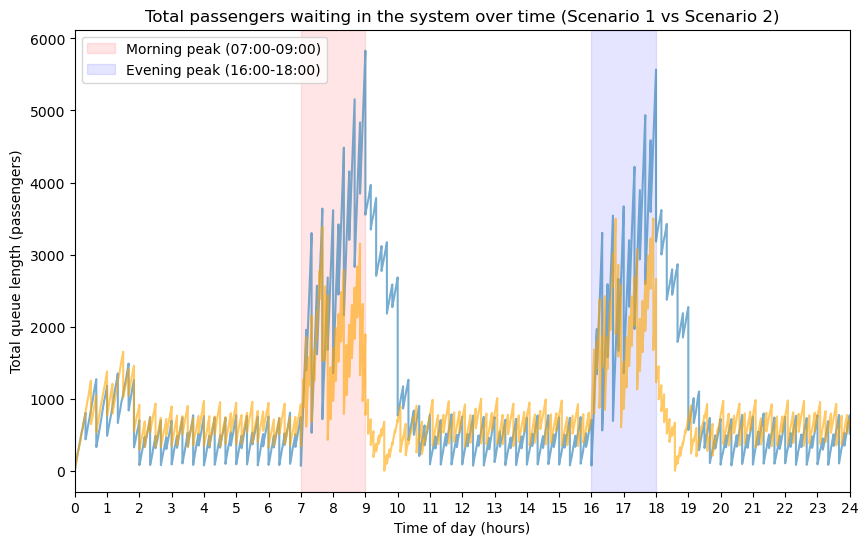

In [60]:
fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(1, 1, 1)

# Plot each simulation run
for t, q in times_queues_scenario1:
    # Convert time from minutes to hours
    t_hours = [time / 60 for time in t] 
    ax.plot(t_hours, q, alpha=0.6)      
    
for t, q in times_queues_scenario2:
    # Convert time from minutes to hours
    t_hours = [time / 60 for time in t] 
    ax.plot(t_hours, q, alpha=0.6, color='orange')     

# Formatting the plot
ax.set(title='Total passengers waiting in the system over time (Scenario 1 vs Scenario 2)',
       xlabel='Time of day (hours)',
       ylabel='Total queue length (passengers)')

# Add vertical lines to show the peak periods (now in hours!)
ax.axvspan(7, 9, color='red', alpha=0.1, label='Morning peak (07:00-09:00)')
ax.axvspan(16, 18, color='blue', alpha=0.1, label='Evening peak (16:00-18:00)')

# Set x-axis limits and ticks to show hours clearly (from 0 to 24, every 2 hours)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 1))

ax.legend()

plt.show()

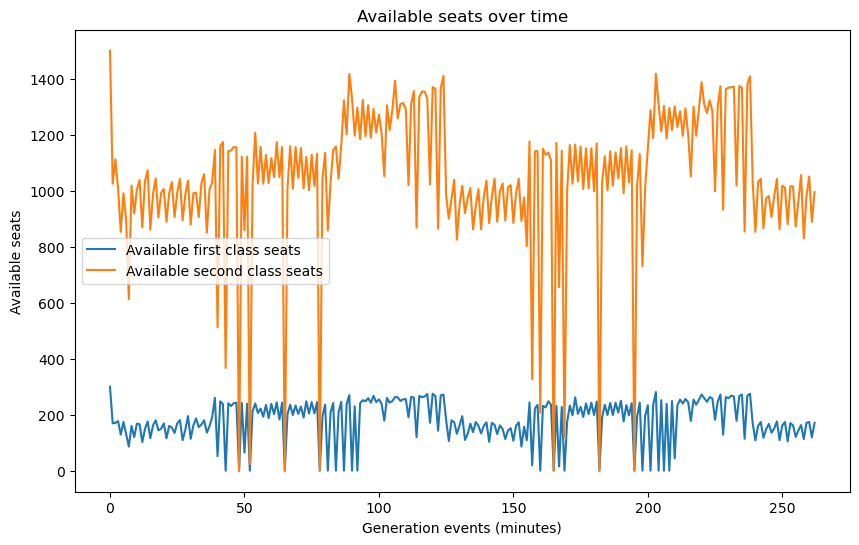

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(empty_seats_first, label='Available first class seats')
plt.plot(empty_seats_second, label='Available second class seats')
plt.xlabel('Generation events (minutes)')
plt.ylabel('Available seats')
plt.title('Available seats over time')
plt.legend()
plt.show()